## IMPORTS Y RUTAS

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path("..")  # si el notebook está dentro de /notebooks
RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

RAW_DIR

WindowsPath('../data/raw')

## LISTAR ARCHIVOS DISPONIBLES

In [2]:
files = list(RAW_DIR.glob("*.csv"))

for file in files:
    print(file.name)

ECB Data Portal_20260519172502.csv
prc_hicp_midx_page_linear_2_0.csv
prc_hpi_q_page_linear_2_0.csv
tespm140_page_linear_2_0.csv
une_rt_q_page_linear_2_0.csv


## CONFIGURAR PAÍSES OBJETIVO

In [3]:
COUNTRY_MAPPING = {
    "Austria": "Austria",
    "Belgium": "Bélgica",
    "Bulgaria": "Bulgaria",
    "Croatia": "Croacia",
    "Cyprus": "Chipre",
    "Czechia": "Chequia",
    "Denmark": "Dinamarca",
    "Estonia": "Estonia",
    "Finland": "Finlandia",
    "France": "Francia",
    "Germany": "Alemania",
    "Greece": "Grecia",
    "Hungary": "Hungría",
    "Ireland": "Irlanda",
    "Italy": "Italia",
    "Latvia": "Letonia",
    "Lithuania": "Lituania",
    "Luxembourg": "Luxemburgo",
    "Malta": "Malta",
    "Netherlands": "Países Bajos",
    "Poland": "Polonia",
    "Portugal": "Portugal",
    "Romania": "Rumanía",
    "Slovakia": "Eslovaquia",
    "Slovenia": "Eslovenia",
    "Spain": "España",
    "Sweden": "Suecia"
}

COUNTRIES = list(COUNTRY_MAPPING.keys())
COUNTRIES

['Austria',
 'Belgium',
 'Bulgaria',
 'Croatia',
 'Cyprus',
 'Czechia',
 'Denmark',
 'Estonia',
 'Finland',
 'France',
 'Germany',
 'Greece',
 'Hungary',
 'Ireland',
 'Italy',
 'Latvia',
 'Lithuania',
 'Luxembourg',
 'Malta',
 'Netherlands',
 'Poland',
 'Portugal',
 'Romania',
 'Slovakia',
 'Slovenia',
 'Spain',
 'Sweden']

## LIMPIAR CSV EUROSTAT

In [4]:
def clean_eurostat_csv(
    file_path,
    value_name,
    country_col="Geopolitical entity (reporting)",
    time_col="TIME_PERIOD",
    value_col="OBS_VALUE"
):
    df = pd.read_csv(file_path)
    
    print(f"\nArchivo: {file_path.name}")
    print("Columnas:", df.columns.tolist())
    
    df = df[[country_col, time_col, value_col]].copy()
    df.columns = ["country_raw", "time", value_name]
    
    df = df[df["country_raw"].isin(COUNTRIES)].copy()
    df["country"] = df["country_raw"].map(COUNTRY_MAPPING)
    
    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")
    
    df = df[["country", "time", value_name]]
    df = df.dropna(subset=[value_name])
    
    return df

## LIMPIAR HOUSE PRICE INDEX

In [5]:
hpi_path = RAW_DIR / "prc_hpi_q_page_linear_2_0.csv"

hpi = clean_eurostat_csv(
    hpi_path,
    value_name="hpi"
)

hpi["date"] = pd.PeriodIndex(hpi["time"], freq="Q").to_timestamp()

hpi = hpi[["date", "country", "hpi"]].sort_values(["country", "date"])

hpi.head()


Archivo: prc_hpi_q_page_linear_2_0.csv
Columnas: ['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'freq', 'Time frequency', 'purchase', 'Purchases', 'unit', 'Unit of measure', 'geo', 'Geopolitical entity (reporting)', 'TIME_PERIOD', 'Time', 'OBS_VALUE', 'Observation value', 'OBS_FLAG', 'Observation status (Flag) V2 structure', 'CONF_STATUS', 'Confidentiality status (flag)']


,date,country,hpi
420,2005-01-01,Alemania,84.2
421,2005-04-01,Alemania,82.7
422,2005-07-01,Alemania,84.4
423,2005-10-01,Alemania,82.0
424,2006-01-01,Alemania,83.2


## LIMPIAR INFLACIÓN HCIP

In [6]:
hicp_path = RAW_DIR / "prc_hicp_midx_page_linear_2_0.csv"

hicp = clean_eurostat_csv(
    hicp_path,
    value_name="hicp"
)

hicp["date_month"] = pd.to_datetime(hicp["time"])
hicp["date"] = hicp["date_month"].dt.to_period("Q").dt.to_timestamp()

hicp_q = (
    hicp
    .groupby(["country", "date"], as_index=False)["hicp"]
    .mean()
    .sort_values(["country", "date"])
)

hicp_q["inflation_yoy"] = (
    hicp_q
    .groupby("country")["hicp"]
    .pct_change(4) * 100
)

hicp_q.head()


Archivo: prc_hicp_midx_page_linear_2_0.csv
Columnas: ['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'freq', 'Time frequency', 'unit', 'Unit of measure', 'coicop', 'Classification of individual consumption by purpose (COICOP)', 'geo', 'Geopolitical entity (reporting)', 'TIME_PERIOD', 'Time', 'OBS_VALUE', 'Observation value', 'OBS_FLAG', 'Observation status (Flag) V2 structure', 'CONF_STATUS', 'Confidentiality status (flag)']


,country,date,hicp,inflation_yoy
0,Alemania,1996-01-01,75.466667,NaN
1,Alemania,1996-04-01,75.700000,NaN
2,Alemania,1996-07-01,75.933333,NaN
3,Alemania,1996-10-01,75.833333,NaN
4,Alemania,1997-01-01,76.666667,1.590106


## LIMPIAR DESEMPLEO

In [7]:
unemp_path = RAW_DIR / "une_rt_q_page_linear_2_0.csv"

unemployment = clean_eurostat_csv(
    unemp_path,
    value_name="unemployment_rate"
)

unemployment["date"] = pd.PeriodIndex(
    unemployment["time"],
    freq="Q"
).to_timestamp()

unemployment = unemployment[
    ["date", "country", "unemployment_rate"]
].sort_values(["country", "date"])

unemployment.head()


Archivo: une_rt_q_page_linear_2_0.csv
Columnas: ['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'freq', 'Time frequency', 's_adj', 'Seasonal adjustment', 'age', 'Age class', 'unit', 'Unit of measure', 'sex', 'Sex', 'geo', 'Geopolitical entity (reporting)', 'TIME_PERIOD', 'Time', 'OBS_VALUE', 'Observation value', 'OBS_FLAG', 'Observation status (Flag) V2 structure', 'CONF_STATUS', 'Confidentiality status (flag)']


,date,country,unemployment_rate
427,2009-01-01,Alemania,7.3
428,2009-04-01,Alemania,7.4
429,2009-07-01,Alemania,7.5
430,2009-10-01,Alemania,7.2
431,2010-01-01,Alemania,7.1


## LIMPIAR HOUSING OVERBURDEN

In [8]:
overburden_path = RAW_DIR / "tespm140_page_linear_2_0.csv"
overburden = clean_eurostat_csv(
    overburden_path,
    value_name="housing_overburden_rate"
)

overburden["year"] = overburden["time"].astype(int)

overburden = overburden[
    ["year", "country", "housing_overburden_rate"]
].sort_values(["country", "year"])

overburden.head()


Archivo: tespm140_page_linear_2_0.csv
Columnas: ['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'freq', 'Time frequency', 'unit', 'Unit of measure', 'rskpovth', 'Risk of poverty threshold', 'age', 'Age class', 'sex', 'Sex', 'geo', 'Geopolitical entity (reporting)', 'TIME_PERIOD', 'Time', 'OBS_VALUE', 'Observation value', 'OBS_FLAG', 'Observation status (Flag) V2 structure', 'CONF_STATUS', 'Confidentiality status (flag)']


,year,country,housing_overburden_rate
78,2014,Alemania,15.9
79,2015,Alemania,15.6
80,2016,Alemania,15.8
81,2017,Alemania,14.5
82,2018,Alemania,14.2


## OVERBURDEN TRIMESTRAL

In [9]:
quarters = hpi[["date", "country"]].copy()
quarters["year"] = quarters["date"].dt.year

overburden_q = quarters.merge(
    overburden,
    on=["country", "year"],
    how="left"
)

overburden_q = overburden_q[
    ["date", "country", "housing_overburden_rate"]
]

overburden_q.head()

,date,country,housing_overburden_rate
0,2005-01-01,Alemania,NaN
1,2005-04-01,Alemania,NaN
2,2005-07-01,Alemania,NaN
3,2005-10-01,Alemania,NaN
4,2006-01-01,Alemania,NaN


## LIMPIAR INTERÉS

In [10]:
ecb_path = RAW_DIR / "ECB Data Portal_20260519172502.csv"
ecb_raw = pd.read_csv(ecb_path)

print(ecb_raw.columns.tolist())
ecb_raw.head()

['DATE', 'TIME PERIOD', 'Main refinancing operations - Minimum bid rate/fixed rate (date of changes) - Level (FM.D.U2.EUR.4F.KR.MRR_RT.LEV)']


,DATE,TIME PERIOD,Main refinancing operations - Minimum bid rate/fixed rate (date of changes) - Level (FM.D.U2.EUR.4F.KR.MRR_RT.LEV)
0,1999-01-01,01 Jan 1999,3.0
1,1999-01-02,02 Jan 1999,3.0
2,1999-01-03,03 Jan 1999,3.0
3,1999-01-04,04 Jan 1999,3.0
4,1999-01-05,05 Jan 1999,3.0


In [11]:
ecb_raw = pd.read_csv(ecb_path)

print(ecb_raw.columns.tolist())
display(ecb_raw.head())

value_col = ecb_raw.columns[2]

ecb = ecb_raw[["DATE", value_col]].copy()

ecb.columns = ["date", "ecb_main_refinancing_rate"]

ecb["date"] = pd.to_datetime(ecb["date"])

ecb["ecb_main_refinancing_rate"] = pd.to_numeric(
    ecb["ecb_main_refinancing_rate"],
    errors="coerce"
)

ecb["date"] = ecb["date"].dt.to_period("Q").dt.to_timestamp()

ecb_q = (
    ecb
    .sort_values("date")
    .groupby("date", as_index=False)["ecb_main_refinancing_rate"]
    .last()
)

ecb_q.head()

['DATE', 'TIME PERIOD', 'Main refinancing operations - Minimum bid rate/fixed rate (date of changes) - Level (FM.D.U2.EUR.4F.KR.MRR_RT.LEV)']


,DATE,TIME PERIOD,Main refinancing operations - Minimum bid rate/fixed rate (date of changes) - Level (FM.D.U2.EUR.4F.KR.MRR_RT.LEV)
0,1999-01-01,01 Jan 1999,3.0
1,1999-01-02,02 Jan 1999,3.0
2,1999-01-03,03 Jan 1999,3.0
3,1999-01-04,04 Jan 1999,3.0
4,1999-01-05,05 Jan 1999,3.0


,date,ecb_main_refinancing_rate
0,1999-01-01,3.0
1,1999-04-01,2.5
2,1999-07-01,2.5
3,1999-10-01,2.5
4,2000-01-01,3.0


In [12]:
ecb_q["date"].agg(["min", "max", "count"])

min      1999-01-01 00:00:00
max      2026-04-01 00:00:00
count                    110
Name: date, dtype: object

In [13]:
ecb_q.head(20)
ecb_q.tail(20)

,date,ecb_main_refinancing_rate
90,2021-07-01,0.00
91,2021-10-01,0.00
92,2022-01-01,0.00
93,2022-04-01,0.00
94,2022-07-01,0.50
95,2022-10-01,1.25
96,2023-01-01,2.50
97,2023-04-01,3.50
98,2023-07-01,4.25
99,2023-10-01,4.50


## DATASET ANALÍTICO FINAL

In [14]:
dataset = hpi.copy()

dataset = dataset.merge(
    hicp_q[["date", "country", "hicp", "inflation_yoy"]],
    on=["date", "country"],
    how="left"
)

dataset = dataset.merge(
    unemployment,
    on=["date", "country"],
    how="left"
)

dataset = dataset.merge(
    overburden_q,
    on=["date", "country"],
    how="left"
)

dataset = dataset.merge(
    ecb_q,
    on="date",
    how="left"
)

dataset = dataset.sort_values(["country", "date"]).reset_index(drop=True)

dataset.head()

,date,country,hpi,hicp,inflation_yoy,unemployment_rate,housing_overburden_rate,ecb_main_refinancing_rate
0,2005-01-01,Alemania,84.2,84.600000,1.764234,NaN,NaN,2.00
1,2005-04-01,Alemania,82.7,85.133333,1.550696,NaN,NaN,2.00
2,2005-07-01,Alemania,84.4,85.933333,2.139461,NaN,NaN,2.00
3,2005-10-01,Alemania,82.0,86.166667,2.254747,NaN,NaN,2.00
4,2006-01-01,Alemania,83.2,86.333333,2.048857,NaN,NaN,2.25


## REVISAR NULOS

In [15]:
missing_summary = (
    dataset
    .isna()
    .sum()
    .reset_index()
)

missing_summary.columns = ["variable", "missing_values"]

missing_summary

,variable,missing_values
0,date,0
1,country,0
2,hpi,0
3,hicp,0
4,inflation_yoy,0
5,unemployment_rate,245
6,housing_overburden_rate,789
7,ecb_main_refinancing_rate,0


## PERIODO ÚTIL

In [16]:
dataset = dataset[
    dataset["date"] >= "2014-01-01"
].copy()

dataset = dataset.sort_values(["country", "date"]).reset_index(drop=True)

dataset.groupby("country")["date"].agg(["min", "max", "count"])

,min,max,count
country,,,
Alemania,2014-01-01,2025-10-01,48
Austria,2014-01-01,2025-10-01,48
Bulgaria,2014-01-01,2025-10-01,48
Bélgica,2014-01-01,2025-10-01,48
Chequia,2014-01-01,2025-10-01,48
Chipre,2014-01-01,2025-10-01,48
Croacia,2014-01-01,2025-10-01,48
Dinamarca,2014-01-01,2025-10-01,48
Eslovaquia,2014-01-01,2025-10-01,48


In [17]:
coverage = (
    dataset
    .groupby("country")
    .agg(
        min_date=("date", "min"),
        max_date=("date", "max"),
        n_rows=("date", "count"),
        missing_hpi=("hpi", lambda x: x.isna().sum()),
        missing_hicp=("hicp", lambda x: x.isna().sum()),
        missing_inflation=("inflation_yoy", lambda x: x.isna().sum()),
        missing_unemployment=("unemployment_rate", lambda x: x.isna().sum()),
        missing_overburden=("housing_overburden_rate", lambda x: x.isna().sum()),
        missing_ecb=("ecb_main_refinancing_rate", lambda x: x.isna().sum())
    )
    .reset_index()
)

coverage.sort_values("n_rows", ascending=False)

,country,min_date,max_date,n_rows,missing_hpi,missing_hicp,missing_inflation,missing_unemployment,missing_overburden,missing_ecb
0,Alemania,2014-01-01,2025-10-01,48,0,0,0,0,0,0
1,Austria,2014-01-01,2025-10-01,48,0,0,0,0,0,0
2,Bulgaria,2014-01-01,2025-10-01,48,0,0,0,0,0,0
3,Bélgica,2014-01-01,2025-10-01,48,0,0,0,0,0,0
4,Chequia,2014-01-01,2025-10-01,48,0,0,0,0,0,0
5,Chipre,2014-01-01,2025-10-01,48,0,0,0,0,0,0
6,Croacia,2014-01-01,2025-10-01,48,0,0,0,0,0,0
7,Dinamarca,2014-01-01,2025-10-01,48,0,0,0,0,0,0
8,Eslovaquia,2014-01-01,2025-10-01,48,0,0,0,0,0,0
9,Eslovenia,2014-01-01,2025-10-01,48,0,0,0,0,0,0


In [18]:
MIN_ROWS = 40

valid_countries = coverage[
    (coverage["n_rows"] >= MIN_ROWS) &
    (coverage["missing_hpi"] == 0) &
    (coverage["missing_hicp"] == 0) &
    (coverage["missing_inflation"] == 0) &
    (coverage["missing_unemployment"] == 0) &
    (coverage["missing_ecb"] == 0)
]["country"].tolist()

valid_countries

['Alemania',
 'Austria',
 'Bulgaria',
 'Bélgica',
 'Chequia',
 'Chipre',
 'Croacia',
 'Dinamarca',
 'Eslovaquia',
 'Eslovenia',
 'España',
 'Estonia',
 'Finlandia',
 'Francia',
 'Hungría',
 'Irlanda',
 'Italia',
 'Letonia',
 'Lituania',
 'Luxemburgo',
 'Malta',
 'Países Bajos',
 'Polonia',
 'Portugal',
 'Rumanía',
 'Suecia']

In [19]:
dataset = dataset[
    dataset["country"].isin(valid_countries)
].copy()

dataset = dataset.sort_values(["country", "date"]).reset_index(drop=True)

dataset["housing_overburden_rate"] = (
    dataset
    .groupby("country")["housing_overburden_rate"]
    .transform(lambda x: x.interpolate(method="linear").ffill().bfill())
)

dataset.isna().sum()

date                         0
country                      0
hpi                          0
hicp                         0
inflation_yoy                0
unemployment_rate            0
housing_overburden_rate      0
ecb_main_refinancing_rate    0
dtype: int64

In [20]:
dataset = dataset[
    dataset["country"].isin(valid_countries)
].copy()

dataset = dataset.sort_values(["country", "date"]).reset_index(drop=True)

dataset.groupby("country")["date"].agg(["min", "max", "count"])

,min,max,count
country,,,
Alemania,2014-01-01,2025-10-01,48
Austria,2014-01-01,2025-10-01,48
Bulgaria,2014-01-01,2025-10-01,48
Bélgica,2014-01-01,2025-10-01,48
Chequia,2014-01-01,2025-10-01,48
Chipre,2014-01-01,2025-10-01,48
Croacia,2014-01-01,2025-10-01,48
Dinamarca,2014-01-01,2025-10-01,48
Eslovaquia,2014-01-01,2025-10-01,48


## DATASET LIMPIO

In [21]:
dataset.head(10)

,date,country,hpi,hicp,inflation_yoy,unemployment_rate,housing_overburden_rate,ecb_main_refinancing_rate
0,2014-01-01,Alemania,93.8,99.066667,0.951087,4.8,15.9,0.25
1,2014-04-01,Alemania,95.7,99.200000,0.915565,4.7,15.9,0.25
2,2014-07-01,Alemania,96.2,99.666667,0.775194,4.6,15.9,0.15
3,2014-10-01,Alemania,96.2,99.333333,0.438153,4.6,15.9,0.05
4,2015-01-01,Alemania,97.8,98.933333,-0.134590,4.5,15.6,0.05
5,2015-04-01,Alemania,99.9,100.433333,1.243280,4.4,15.6,0.05
6,2015-07-01,Alemania,100.4,100.733333,1.070234,4.2,15.6,0.05
7,2015-10-01,Alemania,101.8,99.866667,0.536913,4.3,15.6,0.05
8,2016-01-01,Alemania,103.9,99.066667,0.134771,4.0,15.8,0.05
9,2016-04-01,Alemania,106.9,100.333333,-0.099569,4.0,15.8,0.00


In [22]:
dataset.shape

(1248, 8)

In [23]:
dataset["country"].unique()

array(['Alemania', 'Austria', 'Bulgaria', 'Bélgica', 'Chequia', 'Chipre',
       'Croacia', 'Dinamarca', 'Eslovaquia', 'Eslovenia', 'España',
       'Estonia', 'Finlandia', 'Francia', 'Hungría', 'Irlanda', 'Italia',
       'Letonia', 'Lituania', 'Luxemburgo', 'Malta', 'Países Bajos',
       'Polonia', 'Portugal', 'Rumanía', 'Suecia'], dtype=object)

In [24]:
dataset.isna().sum()

date                         0
country                      0
hpi                          0
hicp                         0
inflation_yoy                0
unemployment_rate            0
housing_overburden_rate      0
ecb_main_refinancing_rate    0
dtype: int64

In [25]:
dataset.sample(20)

,date,country,hpi,hicp,inflation_yoy,unemployment_rate,housing_overburden_rate,ecb_main_refinancing_rate
797,2021-04-01,Italia,102.80,105.100000,1.154957,9.7,7.2,0.00
502,2019-07-01,España,126.26,104.043333,0.434391,14.2,8.5,0.00
838,2019-07-01,Letonia,144.58,108.960000,2.802151,6.2,5.4,0.00
629,2015-04-01,Francia,99.55,100.450000,0.266179,10.4,5.7,0.05
498,2018-07-01,España,120.48,103.593333,2.263903,14.9,8.9,0.00
859,2024-10-01,Letonia,201.90,146.180000,2.580057,7.0,6.7,3.40
953,2024-04-01,Luxemburgo,162.41,125.173333,3.000713,6.4,8.0,4.50
518,2023-07-01,España,150.68,120.696667,2.595416,12.0,8.2,4.25
224,2022-01-01,Chequia,210.00,124.666667,10.226938,2.2,6.9,0.00
915,2014-10-01,Luxemburgo,97.45,99.573333,-0.117029,5.5,6.8,0.05


In [26]:
dataset.duplicated(
    subset=["date", "country"]
).sum()

np.int64(0)

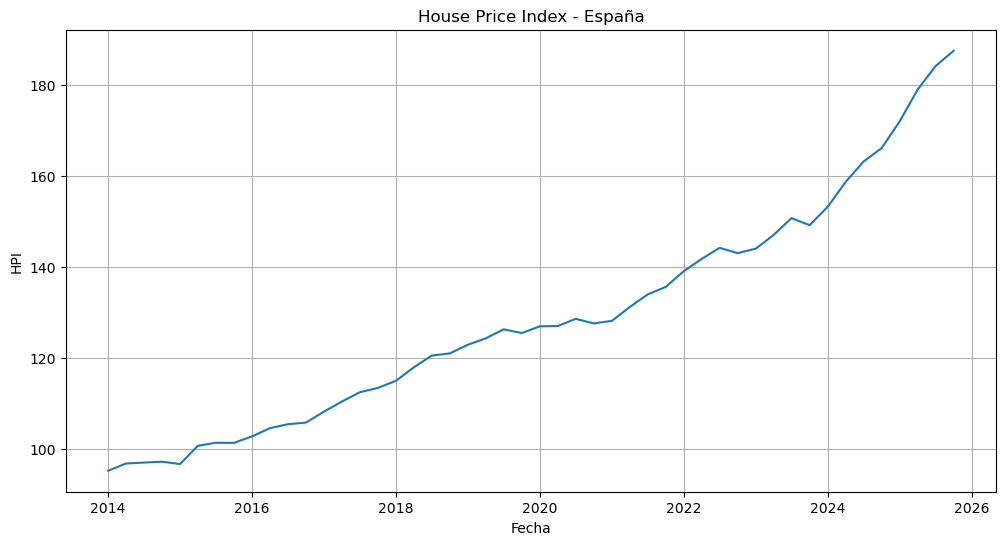

In [27]:
import matplotlib.pyplot as plt

spain = dataset[
    dataset["country"] == "España"
]

plt.figure(figsize=(12,6))

plt.plot(
    spain["date"],
    spain["hpi"]
)

plt.title("House Price Index - España")
plt.xlabel("Fecha")
plt.ylabel("HPI")

plt.grid(True)

plt.show()

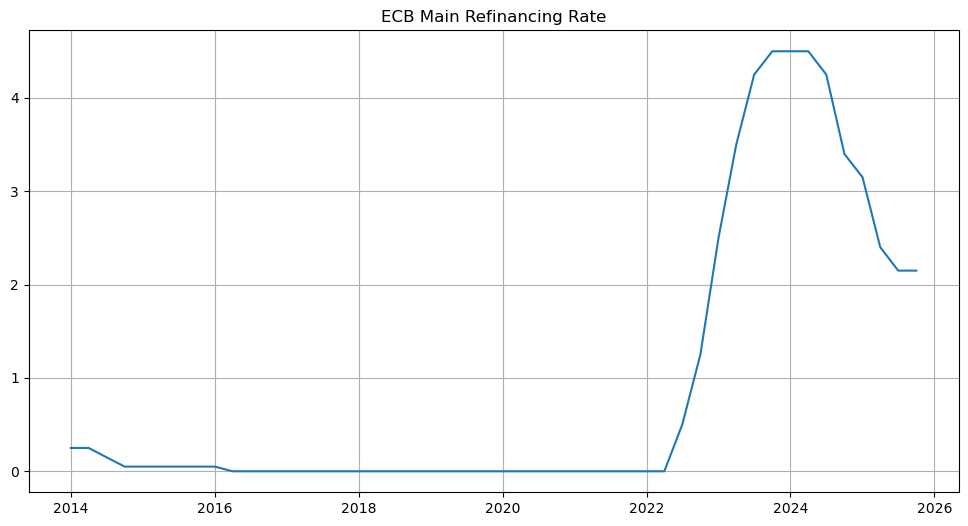

In [28]:
plt.figure(figsize=(12,6))

plt.plot(
    dataset.drop_duplicates("date")["date"],
    dataset.drop_duplicates("date")["ecb_main_refinancing_rate"]
)

plt.title("ECB Main Refinancing Rate")

plt.grid(True)

plt.show()

In [29]:
dataset[
    dataset["housing_overburden_rate"].isna()
].assign(
    year=lambda x: x["date"].dt.year
).groupby(["country", "year"]).size()

Series([], dtype: int64)

In [30]:
dataset["housing_overburden_rate"] = (
    dataset
    .groupby("country")["housing_overburden_rate"]
    .transform(lambda x: x.ffill().bfill())
)

In [31]:
dataset[
    dataset["housing_overburden_rate"].isna()
].assign(
    year=lambda x: x["date"].dt.year
).groupby(["country", "year"]).size()

Series([], dtype: int64)

In [32]:
output_path = PROCESSED_DIR / "housing_dataset_clean.csv"

dataset.to_csv(output_path, index=False)

output_path

WindowsPath('../data/processed/housing_dataset_clean.csv')

## RESUMEN CALIDAD DATOS

In [33]:
quality_summary = dataset.groupby("country").agg(
    min_date=("date", "min"),
    max_date=("date", "max"),
    n_observations=("date", "count"),
    hpi_missing=("hpi", lambda x: x.isna().sum()),
    inflation_missing=("inflation_yoy", lambda x: x.isna().sum()),
    unemployment_missing=("unemployment_rate", lambda x: x.isna().sum()),
    overburden_missing=("housing_overburden_rate", lambda x: x.isna().sum()),
    ecb_rate_missing=("ecb_main_refinancing_rate", lambda x: x.isna().sum())
).reset_index()

quality_summary

,country,min_date,max_date,n_observations,hpi_missing,inflation_missing,unemployment_missing,overburden_missing,ecb_rate_missing
0,Alemania,2014-01-01,2025-10-01,48,0,0,0,0,0
1,Austria,2014-01-01,2025-10-01,48,0,0,0,0,0
2,Bulgaria,2014-01-01,2025-10-01,48,0,0,0,0,0
3,Bélgica,2014-01-01,2025-10-01,48,0,0,0,0,0
4,Chequia,2014-01-01,2025-10-01,48,0,0,0,0,0
5,Chipre,2014-01-01,2025-10-01,48,0,0,0,0,0
6,Croacia,2014-01-01,2025-10-01,48,0,0,0,0,0
7,Dinamarca,2014-01-01,2025-10-01,48,0,0,0,0,0
8,Eslovaquia,2014-01-01,2025-10-01,48,0,0,0,0,0
9,Eslovenia,2014-01-01,2025-10-01,48,0,0,0,0,0


In [34]:
quality_summary.to_csv(
    PROCESSED_DIR / "data_quality_summary.csv",
    index=False
)

In [35]:
coverage_final = (
    dataset
    .groupby("country")
    .agg(
        fecha_inicio=("date", "min"),
        fecha_fin=("date", "max"),
        observaciones=("date", "count"),
        hpi_missing=("hpi", lambda x: x.isna().sum()),
        inflation_missing=("inflation_yoy", lambda x: x.isna().sum()),
        unemployment_missing=("unemployment_rate", lambda x: x.isna().sum()),
        overburden_missing=("housing_overburden_rate", lambda x: x.isna().sum()),
        ecb_missing=("ecb_main_refinancing_rate", lambda x: x.isna().sum())
    )
    .reset_index()
)

coverage_final.to_csv(
    PROCESSED_DIR / "coverage_by_country.csv",
    index=False
)

coverage_final

,country,fecha_inicio,fecha_fin,observaciones,hpi_missing,inflation_missing,unemployment_missing,overburden_missing,ecb_missing
0,Alemania,2014-01-01,2025-10-01,48,0,0,0,0,0
1,Austria,2014-01-01,2025-10-01,48,0,0,0,0,0
2,Bulgaria,2014-01-01,2025-10-01,48,0,0,0,0,0
3,Bélgica,2014-01-01,2025-10-01,48,0,0,0,0,0
4,Chequia,2014-01-01,2025-10-01,48,0,0,0,0,0
5,Chipre,2014-01-01,2025-10-01,48,0,0,0,0,0
6,Croacia,2014-01-01,2025-10-01,48,0,0,0,0,0
7,Dinamarca,2014-01-01,2025-10-01,48,0,0,0,0,0
8,Eslovaquia,2014-01-01,2025-10-01,48,0,0,0,0,0
9,Eslovenia,2014-01-01,2025-10-01,48,0,0,0,0,0


In [36]:
all_countries_es = list(COUNTRY_MAPPING.values())

excluded_countries = sorted(
    set(all_countries_es) - set(valid_countries)
)

excluded_countries

['Grecia']

In [37]:
pd.DataFrame({"excluded_country": excluded_countries}).to_csv(
    PROCESSED_DIR / "excluded_countries.csv",
    index=False
)

In [38]:
import pandas as pd
import plotly.express as px
from pathlib import Path

BASE_DIR = Path("..")
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ISO_MAPPING = {
    "Alemania": "DEU",
    "Austria": "AUT",
    "Bélgica": "BEL",
    "Bulgaria": "BGR",
    "Chequia": "CZE",
    "Chipre": "CYP",
    "Croacia": "HRV",
    "Dinamarca": "DNK",
    "Eslovaquia": "SVK",
    "Eslovenia": "SVN",
    "España": "ESP",
    "Estonia": "EST",
    "Finlandia": "FIN",
    "Francia": "FRA",
    "Grecia": "GRC",
    "Hungría": "HUN",
    "Irlanda": "IRL",
    "Italia": "ITA",
    "Letonia": "LVA",
    "Lituania": "LTU",
    "Luxemburgo": "LUX",
    "Malta": "MLT",
    "Países Bajos": "NLD",
    "Polonia": "POL",
    "Portugal": "PRT",
    "Rumanía": "ROU",
    "Suecia": "SWE"
}

included_countries = sorted(dataset["country"].unique())

map_countries = pd.DataFrame({
    "country": included_countries
})

map_countries["iso_alpha"] = map_countries["country"].map(ISO_MAPPING)
map_countries["included"] = "País incluido"

fig = px.choropleth(
    map_countries,
    locations="iso_alpha",
    color="included",
    hover_name="country",
    projection="natural earth",
    title="Países de la Unión Europea incluidos en el análisis final"
)

fig.update_geos(
    visible=False,
    showcountries=True,
    lataxis_range=[34, 72],
    lonaxis_range=[-12, 35]
)

fig.update_layout(
    showlegend=False,
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.write_html(
    FIGURES_DIR / "included_eu_countries_map.html"
)

fig.show()

c:\Users\usuario\anaconda3\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.


